In [ ]:
import os
from pathlib import Path

def _find_project_root():
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / 'data').is_dir() and (cand / 'notebooks').is_dir():
            return cand
    return Path.cwd()

os.chdir(os.environ.get('ML_IDS_ROOT') or _find_project_root())
print('Project root:', os.getcwd())

Project root: /home/user/22056253/ML-IDS


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 0 — Library import check
#
# Imports every library used across the full project (pandas, sklearn,
# imbalanced-learn, xgboost, torch, shap) and prints a confirmation.
# Run this first to catch missing package errors before the heavy data
# loading cells execute.
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import torch
import shap
print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Load raw CSVs
#
# Reads all 10 CIC-IDS-2018 CSV files from data/raw/.
#
# ⚠ DATA CAVEAT (upstream, not fixable locally): 7 of the 10 files are
# truncated at exactly 1,048,575 rows (2**20 - 1, the Excel row limit).
# This truncation is present in the OFFICIAL "Processed Traffic Data for
# ML Algorithms" CSVs published by the Canadian Institute for Cybersecurity
# — verified byte-for-byte and row-for-row against the source bucket
# s3://cse-cic-ids2018/ (Wednesday-21-02-2018 there is also 1,048,575 rows).
# So this is the canonical dataset used across the literature, NOT a local
# mishap, and re-downloading the processed CSVs would return the same files.
# The only complete data is the raw PCAP capture, which would need to be
# re-run through CICFlowMeter to regenerate features. Consequently the
# per-class / imbalance counts below are LOWER BOUNDS on the true traffic.
# Truncated files are detected and flagged automatically on load.
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import os

EXCEL_ROW_LIMIT = 1_048_575   # 2**20 - 1 data rows => file was cut at the Excel limit

data_folder = 'data/raw/'
all_files = sorted(f for f in os.listdir(data_folder) if f.endswith('.csv'))
print(f'Found {len(all_files)} CSV files:')
for f in all_files:
    print(f'  - {f}')

dfs = []
truncated = []
for f in all_files:
    tmp = pd.read_csv(os.path.join(data_folder, f), low_memory=False)
    dfs.append(tmp)
    flag = ''
    if tmp.shape[0] == EXCEL_ROW_LIMIT:
        truncated.append(f)
        flag = '   ⚠ TRUNCATED at Excel row limit (2**20 - 1)'
    print(f'Loaded {f}: {tmp.shape[0]} rows{flag}')

df = pd.concat(dfs, ignore_index=True)
del dfs
print(f'\nTotal rows: {df.shape[0]}')
print(f'Total columns: {df.shape[1]}')

if truncated:
    print(f'\n⚠ {len(truncated)}/{len(all_files)} files are truncated at the Excel row limit '
          f'({EXCEL_ROW_LIMIT:,} rows):')
    for f in truncated:
        print(f'    - {f}')
    print('  This is inherent to the official CIC processed CSVs (see cell header).')
    print('  Class/imbalance statistics below are lower bounds on the true traffic.')

Found 10 CSV files:
  - 02-14-2018.csv
  - 02-15-2018.csv
  - 02-16-2018.csv
  - 02-20-2018.csv
  - 02-21-2018.csv
  - 02-22-2018.csv
  - 02-23-2018.csv
  - 02-28-2018.csv
  - 03-01-2018.csv
  - 03-02-2018.csv
Loaded 02-14-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)
Loaded 02-15-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)
Loaded 02-16-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)
Loaded 02-20-2018.csv: 7948748 rows
Loaded 02-21-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)
Loaded 02-22-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)
Loaded 02-23-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)
Loaded 02-28-2018.csv: 613104 rows
Loaded 03-01-2018.csv: 331125 rows
Loaded 03-02-2018.csv: 1048575 rows   ⚠ TRUNCATED at Excel row limit (2**20 - 1)

Total rows: 16233002
Total columns: 84

⚠ 7/10 files are truncated at the Excel row limit (1,048,575 rows):
    - 02

In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Class value counts
#
# Prints the raw count of each traffic class in the full dataset.
# Reveals the extreme imbalance: Benign has 13.5 M rows while SQL Injection
# has only 87 — a 155 000 : 1 ratio. This motivates SMOTE oversampling and
# the use of macro-F1 (not accuracy) as the primary evaluation metric.
# ─────────────────────────────────────────────────────────────────────
print(df['Label'].value_counts())

Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Label                             59
Name: count, dtype: int64


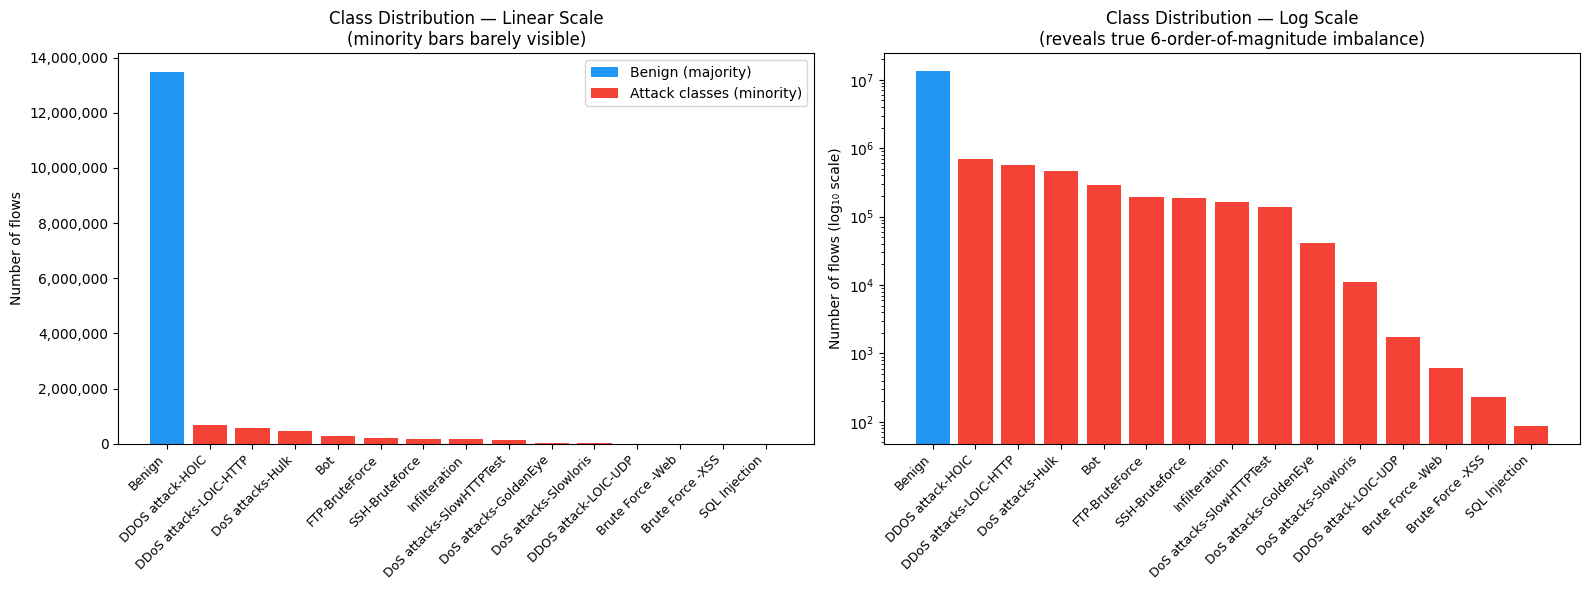

Saved → results/class_distribution.png


In [5]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — Class distribution plot (linear vs log scale)
#
# Plots the class distribution on both linear and log₁₀ scales side-by-side.
# The linear scale shows how completely the Benign class dominates.
# The log scale reveals the full six-order-of-magnitude spread across all
# 15 classes. Saved to results/class_distribution.png.
# ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

label_counts = df['Label'].value_counts()
label_counts = label_counts[label_counts.index != 'Label']   # drop the rogue header row

colors = ['#2196F3' if c == 'Benign' else '#F44336' for c in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- linear scale: majority class dominates and minority classes are invisible ---
axes[0].bar(range(len(label_counts)), label_counts.values, color=colors)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Class Distribution — Linear Scale\n(minority bars barely visible)', fontsize=12)
axes[0].set_ylabel('Number of flows')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- log scale: reveals the full 6-order-of-magnitude spread ---
axes[1].bar(range(len(label_counts)), label_counts.values, color=colors)
axes[1].set_yscale('log')
axes[1].set_xticks(range(len(label_counts)))
axes[1].set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Class Distribution — Log Scale\n(reveals true 6-order-of-magnitude imbalance)', fontsize=12)
axes[1].set_ylabel('Number of flows (log₁₀ scale)')

legend_handles = [
    mpatches.Patch(facecolor='#2196F3', label='Benign (majority)'),
    mpatches.Patch(facecolor='#F44336', label='Attack classes (minority)'),
]
axes[0].legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/class_distribution.png")

In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Imbalance statistics and naive baseline
#
# Quantifies the imbalance ratio for every class and proves that accuracy
# is a misleading metric for this dataset.
# A classifier that always predicts Benign achieves ~83 % accuracy while
# catching 0 % of attacks — demonstrating why macro-F1 must be used instead.
# Also motivates four design choices made in preprocessing and training:
#   1. SMOTE oversampling for rare attack classes.
#   2. class_weight="balanced" in tree models and the MLP.
#   3. Per-class threshold calibration at evaluation time.
#   4. Reporting macro-averaged metrics alongside weighted metrics.
#
# ⚠ NOTE: these counts are recomputed straight from the raw Label columns,
# so they match the files on disk exactly — but 7 of those files are
# truncated at the Excel row limit (see CELL 1). The per-class counts and
# imbalance ratios below are therefore LOWER BOUNDS on the true dataset;
# the real imbalance may be larger still.
# ─────────────────────────────────────────────────────────────────────
# Quantify the imbalance and show why accuracy alone is a misleading metric

# Recompute counts directly from the raw Label columns (cheap, memory-light)
# so the imbalance statistics match the files exactly, independent of any
# processing applied to `df` above.
import glob
true_counts = pd.Series(dtype='int64')
for _f in sorted(glob.glob(data_folder + '*.csv')):
    _c = pd.read_csv(_f, usecols=['Label'])['Label'].astype(str).str.strip().value_counts()
    true_counts = true_counts.add(_c, fill_value=0)
label_counts = true_counts[true_counts.index != 'Label'].sort_values(ascending=False).astype('int64')

total          = label_counts.sum()
majority_count = label_counts.iloc[0]
majority_class = label_counts.index[0]

print("=== Dataset Imbalance Statistics ===")
print("(computed on the truncated files as loaded — counts are lower bounds)\n")
print(f"{'Class':<30} {'Count':>12} {'% of data':>10} {'Imbalance ratio':>17}")
print("─" * 73)
for cls, cnt in label_counts.items():
    pct   = cnt / total * 100
    ratio = majority_count / cnt
    bar   = '█' * min(int(pct / 2), 35)
    print(f"{cls:<30} {cnt:>12,} {pct:>9.3f}%  {ratio:>14.1f}×  {bar}")

print("─" * 73)
print(f"Total flows: {total:,}\n")

minority_min   = label_counts.iloc[-1]
minority_class = label_counts.index[-1]
ratio_max      = majority_count / minority_min

print(f"Largest imbalance: {majority_class} ({majority_count:,}) vs {minority_class} ({minority_min:,})")
print(f"  → {ratio_max:,.0f} : 1 ratio\n")

naive_acc = majority_count / total * 100
print(f"Naive baseline — predict '{majority_class}' for every flow:")
print(f"  Accuracy : {naive_acc:.1f}%   ← looks good on paper")
print(f"  Recall on any attack class : 0.0%   ← catches nothing")
print()
print("Why this proves imbalance must be handled:")
print("  1. A trivial classifier that ignores all features achieves {:.1f}% accuracy.".format(naive_acc))
print("  2. Accuracy is therefore a misleading metric — we use macro-F1 instead.")
print("  3. Rare classes (e.g. SQL Injection, Brute Force-XSS) need SMOTE to provide")
print("     enough examples for the model to learn from.")
print("  4. Tree models and MLP use class_weight='balanced' so rare classes are not")
print("     swamped by the majority during training.")

=== Dataset Imbalance Statistics ===
(computed on the truncated files as loaded — counts are lower bounds)

Class                                 Count  % of data   Imbalance ratio
─────────────────────────────────────────────────────────────────────────
Benign                           13,484,708    83.070%             1.0×  ███████████████████████████████████
DDOS attack-HOIC                    686,012     4.226%            19.7×  ██
DDoS attacks-LOIC-HTTP              576,191     3.550%            23.4×  █
DoS attacks-Hulk                    461,912     2.846%            29.2×  █
Bot                                 286,191     1.763%            47.1×  
FTP-BruteForce                      193,360     1.191%            69.7×  
SSH-Bruteforce                      187,589     1.156%            71.9×  
Infilteration                       161,934     0.998%            83.3×  
DoS attacks-SlowHTTPTest            139,890     0.862%            96.4×  
DoS attacks-GoldenEye                41,

In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — DataFrame schema and summary statistics
#
# Prints df.info() to show column dtypes and df.describe() for numeric stats.
# Key finding: almost all 84 columns are object dtype at this stage because
# CICFlowMeter writes Infinity/NaN as plain strings, preventing pandas from
# inferring numeric types on load. Conversion is handled in preprocessing.
# ─────────────────────────────────────────────────────────────────────
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 16233002 entries, 0 to 16233001
Data columns (total 84 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           object 
 1   Protocol           object 
 2   Timestamp          str    
 3   Flow Duration      object 
 4   Tot Fwd Pkts       object 
 5   Tot Bwd Pkts       object 
 6   TotLen Fwd Pkts    object 
 7   TotLen Bwd Pkts    object 
 8   Fwd Pkt Len Max    object 
 9   Fwd Pkt Len Min    object 
 10  Fwd Pkt Len Mean   object 
 11  Fwd Pkt Len Std    object 
 12  Bwd Pkt Len Max    object 
 13  Bwd Pkt Len Min    object 
 14  Bwd Pkt Len Mean   object 
 15  Bwd Pkt Len Std    object 
 16  Flow Byts/s        object 
 17  Flow Pkts/s        object 
 18  Flow IAT Mean      object 
 19  Flow IAT Std       object 
 20  Flow IAT Max       object 
 21  Flow IAT Min       object 
 22  Fwd IAT Tot        object 
 23  Fwd IAT Mean       object 
 24  Fwd IAT Std        object 
 25  Fwd IAT Max        object 


In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 — Missing value and infinity audit
#
# Checks for two distinct kinds of missing data:
#   1. True NaN values (pd.isnull) — reported as "Missing values".
#   2. String literals "Infinity" / "NaN" written by CICFlowMeter into
#      feature columns — invisible to isnull() but counted explicitly.
# Both become NaN after pd.to_numeric(errors="coerce") in preprocessing,
# and are then imputed with column medians computed on training data only.
#
# NOTE: the raw isnull() total is dominated by STRUCTURAL NaNs — only the
# 02-20-2018 file carries the 4 extra columns (Flow ID, Src IP, Src Port,
# Dst IP), so they are NaN for every row of the other 9 files. Genuine
# missingness in the 77 model features is far smaller; both are printed.
# ─────────────────────────────────────────────────────────────────────
import numpy as np

total_missing = df.isnull().sum().sum()
print('Missing values (all columns, incl. structural):', total_missing)

# Structural NaNs from the 4 columns present only in 02-20-2018.csv
extra_cols = [c for c in ['Flow ID', 'Src IP', 'Src Port', 'Dst IP'] if c in df.columns]
structural = df[extra_cols].isnull().sum().sum() if extra_cols else 0
print(f'  of which structural (cols only in 02-20 file {extra_cols}): {structural}')
print(f'  genuine NaN in the other columns: {total_missing - structural}')

# CICFlowMeter writes 'Infinity'/'NaN' as text into the numeric feature
# columns. Scan the whole frame: numeric columns cannot match these string
# literals, so this equals scanning only the string columns — and it avoids
# the object-vs-str select_dtypes ambiguity introduced in pandas 3.
INF_STRINGS = {'Infinity', 'infinity', '-Infinity', 'nan', 'NaN'}
str_inf_count = df.isin(INF_STRINGS).sum().sum()
print(f"\nString 'Infinity'/'NaN' literals in feature columns: {str_inf_count}")
print("(These become NaN after pd.to_numeric in preprocessing — handled there.)")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'\nNumeric columns at this stage: {numeric_cols}')
if numeric_cols:
    print('Infinite values (numeric cols only):', np.isinf(df[numeric_cols]).sum().sum())

Missing values (all columns, incl. structural): 33196737
  of which structural (cols only in 02-20 file ['Flow ID', 'Src IP', 'Src Port', 'Dst IP']): 33137016
  genuine NaN in the other columns: 59721

String 'Infinity'/'NaN' literals in feature columns: 12301
(These become NaN after pd.to_numeric in preprocessing — handled there.)

Numeric columns at this stage: ['Src Port']
Infinite values (numeric cols only): 0
